# 67: Crash Diagnostics

Tools for inspecting the `00_fiducial` grid's crashed CHE models — the same set nb63WIP's grid-coverage plot draws as open circles (`is_che & is_handled_crash & ~is_He_depleted`).

1. Preamble
2. Crash inventory (bash-assisted)
3. `MesaModel` — resolves a `(m_zams, p_spin_zams, z_key)` triple to its data
4. Diagnostic functions built on `MesaModel`
5. Tutorial
6. HRD per metallicity, with evolutionary milestone markers

## 1. Preamble

In [1]:
nb_id = 67

### Imports

In [2]:
from pathlib import Path
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mesa_reader as mr

import sys
sys.path.append('..')
from src.util import DATA_DIR, MESA_DATA_DIR
from src.popsynth import get_complete_core_props_df

plt.style.use('./plotstyle.mplstyle')

OUTPUT_FOLDER = DATA_DIR / 'nb_output' / f'nb{nb_id}'
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

/home/hd/hd_hd/hd_lt355/.pyenv/versions/cher/lib/python3.10/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## 2. Crash inventory

Every model the nb63WIP grid-coverage plot tags as a crash: `is_che & is_handled_crash & ~is_He_depleted` in `00_fiducial_core_props_df_v7.h5`. Confirmed earlier that in `00_fiducial` this set is identical to the plot's "CHE, not He-depleted" open-circle layer (all 28 of them are `is_handled_crash`, none `is_unhandled_crash`).

In [9]:
core_props_df = get_complete_core_props_df(DATA_DIR / '00_fiducial_core_props_df_v7.h5')

crashes_df = core_props_df[
    (core_props_df.is_che == True)
    & (core_props_df.is_handled_crash == True)
    & (core_props_df.is_He_depleted == False)
][['z_key', 'm_zams', 'p_spin_zams']].sort_values(
    ['z_key', 'm_zams', 'p_spin_zams']
).reset_index(drop=True)

print(f'{len(crashes_df)} crashed models')
crashes_df

28 crashed models


,z_key,m_zams,p_spin_zams
0,0.0200,60.0,1.2
1,0.0200,70.0,1.2
2,0.0200,80.0,1.0
3,0.0200,80.0,1.1
4,0.0200,80.0,1.2
5,0.0200,90.0,0.9
6,0.0200,90.0,1.0
7,0.0200,90.0,1.1
8,0.0200,90.0,1.2
9,0.0200,90.0,1.3


In [ ]:
z_key	m_zams	p_spin_zams
0	0.0200	60.0	1.2
1	0.0200	70.0	1.2
2	0.0200	80.0	1.0
3	0.0200	80.0	1.1
4	0.0200	80.0	1.2
5	0.0200	90.0	0.9
6	0.0200	90.0	1.0
7	0.0200	90.0	1.1
8	0.0200	90.0	1.2
9	0.0200	90.0	1.3
10	0.0200	100.0	0.9

### Resolve each crash's on-disk path

`Z_FOLDER_MAP` / `MASS_FOLDER_MAP` / `get_run_path` are carried over verbatim from `615_HeBurningCrashDebugger.ipynb`, which already solved this for the same grid.

In [4]:
VARIANT_DIR = MESA_DATA_DIR / '00_fiducial'

Z_FOLDER_MAP = {
    '0.0200': '0002_ZdivZsun_2d-02',
    '0.0400': '0003_ZdivZsun_4d-02',
    '0.0800': '0004_ZdivZsun_8d-02',
    '0.1000': '0005_ZdivZsun_1d-01',
    '0.2000': '0006_ZdivZsun_2d-01',
    '0.3000': '0007_ZdivZsun_3d-01',
    '0.4000': '0008_ZdivZsun_4d-01',
}

MASSES = [10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100,
          120, 140, 160, 180, 200, 220, 240, 260, 280, 300]
MASS_FOLDER_MAP = {m: f'{i + 1:03d}_m{m}' for i, m in enumerate(MASSES)}


def get_run_path(z_key, m_zams, p_spin_zams, variant_dir=VARIANT_DIR):
    """Absolute path to a model's run directory.

    Matched by exact z_key/mass folder, then nearest folder-encoded period
    (folder names round p_spin_zams to 3 decimals).
    """
    mass_dir = variant_dir / Z_FOLDER_MAP[z_key] / MASS_FOLDER_MAP[int(m_zams)]
    for rf in mass_dir.iterdir():
        if not rf.is_dir() or not rf.name.startswith('m'):
            continue
        p = float(rf.name.split('_')[1].lstrip('p').replace('d', 'e'))
        if abs(p - p_spin_zams) < 0.001:
            return rf
    return None


crashes_df['run_path'] = crashes_df.apply(
    lambda r: get_run_path(r.z_key, r.m_zams, r.p_spin_zams), axis=1
)
crashes_df['log_path'] = crashes_df.run_path.apply(lambda p: Path(str(p) + '.log'))

assert crashes_df.run_path.notna().all(), 'some crashes could not be located on disk'
assert crashes_df.log_path.apply(lambda p: p.exists()).all(), 'some terminal logs are missing'

### Extract each crash's termination reason — using bash

`grep`-ing 28 multi-MB, partly-binary terminal logs is both simpler and faster in bash than in Python. Priority order: the MESA `termination code:` line (numerical solver failures write this), then the `stop because ...` line (clean stopping criteria, e.g. hitting critical rotation or a model-number cap — MESA does *not* also emit a `termination code:` line for these). If neither is present the log ends abruptly mid-step with no shutdown message at all — almost always an externally-killed job (walltime/OOM), not a MESA-internal failure.

In [5]:
log_paths_file = OUTPUT_FOLDER / 'crash_log_paths.txt'
log_paths_file.write_text('\n'.join(str(p) for p in crashes_df.log_path) + '\n')

bash_script = r'''
while IFS= read -r log; do
    reason=$(grep -a -m1 "termination code:" "$log")
    if [ -z "$reason" ]; then
        reason=$(grep -a -m1 "stop because" "$log")
    fi
    if [ -z "$reason" ]; then
        reason="(no termination message in log -- likely killed externally, e.g. walltime/OOM)"
    fi
    printf '%s\t%s\n' "$log" "$reason"
done < "$1"
'''

result = subprocess.run(
    ['bash', '-c', bash_script, '_', str(log_paths_file)],
    capture_output=True, text=True, check=True,
)

reason_map = {}
for line in result.stdout.splitlines():
    path, _, reason = line.partition('\t')
    reason_map[path] = reason.strip()

crashes_df['termination_reason'] = crashes_df.log_path.astype(str).map(reason_map)
assert crashes_df.termination_reason.notna().all()

### Classify the reason text

In [6]:
def classify_reason(reason):
    if 'dt_div_kh' in reason or 'min_timestep_limit' in reason:
        return 'numerical: timestep collapse'
    if 'max_model_number' in reason:
        return 'hit max_model_number cap'
    if 'omega_crit' in reason:
        return 'reached critical rotation'
    if 'no termination message' in reason:
        return 'no termination message (likely killed externally)'
    return 'other'


crashes_df['crash_category'] = crashes_df.termination_reason.apply(classify_reason)
print(crashes_df.crash_category.value_counts().to_string())

crash_category
numerical: timestep collapse                         13
reached critical rotation                            10
no termination message (likely killed externally)     4
hit max_model_number cap                              1


### Runtime and SLURM job id -- if recoverable

Each mass folder's `run_grid` is dispatched as one `disBatch` task stream under a single `sbatch` submission (`dispatch_grid`), so there is one SLURM job per submission (often covering a whole metallicity folder's masses, not one job per model) and disBatch itself logs per-task wall time. Two files, both living in the metallicity folder rather than the run's own folder:

- `slurm-<jobid>.out` -- its filename *is* the SLURM job id.
- `*_status.txt` -- one tab-separated line per disBatch task: field 7 (0-indexed) is elapsed seconds, the last field is the task's shell command (`cd <mass>/<run> ; ./rn`), which is how a line is matched back to a model.

Neither file is guaranteed to still exist -- some metallicity folders in this grid have no `status.txt` (no per-model runtime recoverable) and/or no `slurm-*.out` (no job id recoverable); both come back `None` where that's the case rather than being guessed at.

In [7]:
import re


def find_slurm_job_id(z_folder):
    matches = list(Path(z_folder).glob('slurm-*.out'))
    if len(matches) != 1:
        return None
    m = re.match(r'slurm-(\d+)\.out', matches[0].name)
    return int(m.group(1)) if m else None


def find_runtime_hours(z_folder, rel_path):
    """`rel_path` is '<mass_folder>/<run_folder>', as disBatch's command field has it."""
    needle = f'cd {rel_path} ;'
    hours = None
    for status_file in sorted(Path(z_folder).glob('*_status.txt')):
        for line in status_file.read_text(errors='replace').splitlines():
            fields = line.split('\t')
            if len(fields) < 15 or needle not in fields[-1]:
                continue
            try:
                hours = float(fields[7]) / 3600.0
            except ValueError:
                continue
    return hours


z_folders = crashes_df.run_path.apply(lambda p: p.parent.parent)
rel_paths = crashes_df.run_path.apply(lambda p: f'{p.parent.name}/{p.name}')

crashes_df['slurm_job_id'] = z_folders.apply(find_slurm_job_id)
crashes_df['runtime_hours'] = [
    find_runtime_hours(zf, rp) for zf, rp in zip(z_folders, rel_paths)
]

print(f'runtime recovered for {crashes_df.runtime_hours.notna().sum()}/{len(crashes_df)}')
print(f'job id recovered for  {crashes_df.slurm_job_id.notna().sum()}/{len(crashes_df)}')

runtime recovered for 12/28
job id recovered for  27/28


### The readable table

In [8]:
readable_table = (
    crashes_df[['z_key', 'm_zams', 'p_spin_zams', 'crash_category',
                'runtime_hours', 'slurm_job_id', 'termination_reason']]
    .sort_values(['z_key', 'm_zams', 'p_spin_zams'])
    .reset_index(drop=True)
)
readable_table

,z_key,m_zams,p_spin_zams,crash_category,runtime_hours,slurm_job_id,termination_reason
0,0.0200,60.0,1.2,numerical: timestep collapse,NaN,5284184.0,stop because dt_div_kh <= dt_div_kh_minimum
1,0.0200,70.0,1.2,numerical: timestep collapse,NaN,5284184.0,termination code: min_timestep_limit
2,0.0200,80.0,1.0,numerical: timestep collapse,NaN,5284184.0,termination code: min_timestep_limit
3,0.0200,80.0,1.1,numerical: timestep collapse,NaN,5284184.0,termination code: min_timestep_limit
4,0.0200,80.0,1.2,numerical: timestep collapse,NaN,5284184.0,stop because dt_div_kh <= dt_div_kh_minimum
5,0.0200,90.0,0.9,numerical: timestep collapse,NaN,5284184.0,stop because dt_div_kh <= dt_div_kh_minimum
6,0.0200,90.0,1.0,hit max_model_number cap,NaN,5284184.0,termination code: max_model_number
7,0.0200,90.0,1.1,numerical: timestep collapse,NaN,5284184.0,termination code: min_timestep_limit
8,0.0200,90.0,1.2,numerical: timestep collapse,NaN,5284184.0,stop because dt_div_kh <= dt_div_kh_minimum
9,0.0200,90.0,1.3,numerical: timestep collapse,NaN,5284184.0,termination code: min_timestep_limit


## 3. `MesaModel`

Resolves a `(m_zams, p_spin_zams, z_key)` triple to everything the section 4 functions need. The triple must match a row of `crashes_df` **exactly** — this class only ever points at models section 2 already confirmed are crashes; it is not a general-purpose grid loader.

In [8]:
class MesaModel:
    """A single crashed grid model, resolved from `crashes_df` (section 2)."""

    def __init__(self, m_zams, p_spin_zams, z_key, crashes_df=crashes_df):
        match = crashes_df[
            np.isclose(crashes_df.m_zams, m_zams)
            & np.isclose(crashes_df.p_spin_zams, p_spin_zams)
            & (crashes_df.z_key == z_key)
        ]
        if len(match) != 1:
            raise ValueError(
                f'(m_zams={m_zams}, p_spin_zams={p_spin_zams}, z_key={z_key!r}) is '
                f'not one of the {len(crashes_df)} crashed models in crashes_df '
                f'(section 2) -- pass the exact values from that table.'
            )
        row = match.iloc[0]
        self.m_zams = row.m_zams
        self.p_spin_zams = row.p_spin_zams
        self.z_key = row.z_key
        self.termination_reason = row.termination_reason
        self.crash_category = row.crash_category
        self.run_path = row.run_path
        self.log_path = row.log_path
        self.logs_dir = self.run_path / 'LOGS'

        self.history = mr.MesaData(str(self.logs_dir / 'history.data'))
        self.logs = mr.MesaLogDir(str(self.logs_dir))
        self.profiles_index = self._load_profiles_index()

    def _load_profiles_index(self):
        idx = np.atleast_2d(np.loadtxt(self.logs_dir / 'profiles.index', skiprows=1))
        return pd.DataFrame(
            idx, columns=['model_number', 'priority', 'profile_number']
        ).astype(int)

    def __repr__(self):
        return (f'MesaModel(m_zams={self.m_zams:g}, p_spin_zams={self.p_spin_zams:g}, '
                f'z_key={self.z_key!r})')

## 4. Diagnostic functions

Each takes a `MesaModel` (plus whatever else it needs) as its first argument.

- **a** `report_crash` — identity, path, how far the run got, why it stopped
- **b** `get_history_array` — one column of `history.data`
- **c** `nearest_profile` — profile number closest to a given age or model number
- **d** `get_profile_array` — one column from one saved profile
- **e** `list_history_columns`
- **f** `list_profile_columns`

In [10]:
# a
def report_crash(model):
    """Print identity, path, how far the run got, and why it stopped.

    'How far it got' is the last model *saved* to history.data -- the last
    point we actually have data for, regardless of which of the crash
    categories in section 2 produced the stop.
    """
    print(f'Model: M_ZAMS={model.m_zams:g} Msun, P_spin,i={model.p_spin_zams:g} d, '
          f'Z/Zsun={float(model.z_key):g}  (00_fiducial)')
    print(f'Path:  {model.run_path}')
    print(f'Log:   {model.log_path}')
    print()

    model_number = get_history_array(model, 'model_number')[-1]
    age = get_history_array(model, 'star_age')[-1]
    log_teff = get_history_array(model, 'log_Teff')[-1]
    mass = get_history_array(model, 'star_mass')[-1]
    c_h1 = get_history_array(model, 'center_h1')[-1]
    c_he4 = get_history_array(model, 'center_he4')[-1]

    print(f'Last saved model:        {model_number}')
    print(f'Age at crash:            {age:.4g} yr')
    print(f'Surface Teff at crash:   {10 ** log_teff:.4g} K  (log_Teff={log_teff:.4f})')
    print(f'Mass at crash:           {mass:.4g} Msun')
    print(f'center_h1 / center_he4:  {c_h1:.4g} / {c_he4:.4g}')
    print()
    print(f'Crash category: {model.crash_category}')
    print(f'Crash reason:   {model.termination_reason}')

In [11]:
# b
def get_history_array(model, column):
    """Full time series of `column` from history.data (index 0 = earliest)."""
    return model.history.__getattr__(column)

In [12]:
# c
def nearest_profile(model, age=None, model_number=None):
    """Profile number closest to a target age [yr] or model_number.

    Exactly one of `age`/`model_number` must be given. Returns
    `(profile_number, actual_age, actual_model_number)` for the closest match.
    """
    if (age is None) == (model_number is None):
        return model.profiles_index.iloc[-1]

    idx = model.profiles_index
    mn_to_age = dict(zip(
        get_history_array(model, 'model_number'), get_history_array(model, 'star_age')
    ))
    ages = np.array([mn_to_age[mn] for mn in idx.model_number])

    if age is not None:
        i = int(np.argmin(np.abs(ages - age)))
    else:
        i = int(np.argmin(np.abs(idx.model_number.values - model_number)))

    row = idx.iloc[i]
    return int(row.profile_number), float(ages[i]), int(row.model_number)

In [13]:
# d
def get_profile_array(model, profile_number, column):
    """One column from the given saved profile (index 0 = surface)."""
    prof = model.logs.profile_data(profile_number=profile_number)
    return prof.__getattr__(column)

In [14]:
# e
def list_history_columns(model):
    return list(model.history.bulk_names)

In [15]:
# f
def list_profile_columns(model, profile_number=None):
    """Columns available in a saved profile (default: the last one saved)."""
    if profile_number is None:
        prof = model.logs.profile_data()
    else:
        prof = model.logs.profile_data(profile_number=profile_number)
    return list(prof.bulk_names)

## 5. Tutorial

Using the lowest-mass crash (`M_ZAMS=25`, `P=0.6d`, `Z/Zsun=0.08`) as the running example.

In [16]:
model = MesaModel(25, 0.6, '0.0800')
model

MesaModel(m_zams=25, p_spin_zams=0.6, z_key='0.0800')

**a** — the crash report:

In [17]:
report_crash(model)

Model: M_ZAMS=25 Msun, P_spin,i=0.6 d, Z/Zsun=0.08  (00_fiducial)
Path:  /mnt/sds-hd/sd23g011/desa/ceph/mesa_che_grids/sse_production/00_fiducial/0004_ZdivZsun_8d-02/004_m25/m2.500d+01_p6.000d-01_w1.212d-04
Log:   /mnt/sds-hd/sd23g011/desa/ceph/mesa_che_grids/sse_production/00_fiducial/0004_ZdivZsun_8d-02/004_m25/m2.500d+01_p6.000d-01_w1.212d-04.log

Last saved model:        1137
Age at crash:            9.462e+06 yr
Surface Teff at crash:   1.381e+04 K  (log_Teff=4.1403)
Mass at crash:           23.59 Msun
center_h1 / center_he4:  1.892e-18 / 0.9982

Crash category: numerical: timestep collapse
Crash reason:   termination code: min_timestep_limit


**b** — pull an array straight from `history.data`:

In [18]:
log_l = get_history_array(model, 'log_L')
print(f'{len(log_l)} points, log_L[:5] = {log_l[:5]}')

1137 points, log_L[:5] = [5.01569028 4.98565704 4.97027247 4.96067522 4.95408277]


**c** — closest saved profile to a given age (or `model_number=...` instead):

In [19]:
profile_number, actual_age, actual_model_number = nearest_profile(model, age=9.46e6)
print(f'profile {profile_number}: age={actual_age:.5g} yr, model_number={actual_model_number}')

profile 3: age=9.4585e+06 yr, model_number=1000


**d** — pull an array from that profile:

In [20]:
logT = get_profile_array(model, profile_number, 'logT')
print(f'{len(logT)} zones (index 0 = surface), logT[:5] = {logT[:5]}')

2234 zones (index 0 = surface), logT[:5] = [4.78262141 4.78322142 4.78453141 4.78741756 4.79156189]


**e**, **f** — what columns exist:

In [21]:
print('history columns:', len(list_history_columns(model)))
print(list_history_columns(model)[:10], '...')
print()
print('profile columns:', len(list_profile_columns(model)))
print(list_profile_columns(model)[:10], '...')

history columns: 514
['model_number', 'num_zones', 'star_age', 'star_age_sec', 'log_dt', 'star_mass', 'log_xmstar', 'star_mdot', 'log_abs_mdot', 'mass_conv_core'] ...

profile columns: 253
['zone', 'mass', 'logR', 'logT', 'logRho', 'logP', 'x_mass_fraction_H', 'y_mass_fraction_He', 'z_mass_fraction_metals', 'dm'] ...


In [22]:
final_profile_number, final_age, final_model_number = nearest_profile(model, age=1e10)
print(f'profile {final_profile_number}: age={final_age:.5g} yr, model_number={final_model_number}')

profile 3: age=9.4585e+06 yr, model_number=1000


In [23]:
list_profile_columns(model, profile_number=final_profile_number)

['zone',
 'mass',
 'logR',
 'logT',
 'logRho',
 'logP',
 'x_mass_fraction_H',
 'y_mass_fraction_He',
 'z_mass_fraction_metals',
 'dm',
 'logdq',
 'log_g',
 'radius',
 'velocity',
 'scale_height',
 'pressure_scale_height',
 'dq',
 'energy',
 'entropy',
 'prad',
 'pgas',
 'pgas_div_ptotal',
 'eta',
 'mu',
 'grada',
 'dE_dRho',
 'cp',
 'gamma1',
 'csound',
 'v_div_cs',
 'net_nuclear_energy',
 'net_energy',
 'eps_nuc',
 'non_nuc_neu',
 'pp',
 'cno',
 'tri_alpha',
 'c_alpha',
 'n_alpha',
 'o_alpha',
 'ne_alpha',
 'na_alpha',
 'mg_alpha',
 'si_alpha',
 's_alpha',
 'ar_alpha',
 'ca_alpha',
 'ti_alpha',
 'cr_alpha',
 'fe_co_ni',
 'c12_c12',
 'c12_o16',
 'o16_o16',
 'pnhe4',
 'photo',
 'ni56_co56',
 'co56_fe56',
 'other',
 'abar',
 'zbar',
 'z2bar',
 'ye',
 'neut',
 'h1',
 'h2',
 'he3',
 'he4',
 'li7',
 'be7',
 'be9',
 'be10',
 'b8',
 'c12',
 'c13',
 'n13',
 'n14',
 'n15',
 'o14',
 'o15',
 'o16',
 'o17',
 'o18',
 'f17',
 'f18',
 'f19',
 'ne18',
 'ne19',
 'ne20',
 'ne21',
 'ne22',
 'na21',
 'na2

In [24]:
unique_z_keys = crashes_df['z_key'].unique()
print([(i, key) for i, key in enumerate(unique_z_keys)])

pick_z_key = unique_z_keys[0]

[(0, '0.0200'), (1, '0.0400'), (2, '0.0800'), (3, '0.1000'), (4, '0.2000'), (5, '0.3000'), (6, '0.4000')]


In [25]:
crashes_df.columns

Index(['z_key', 'm_zams', 'p_spin_zams', 'run_path', 'log_path',
       'termination_reason', 'crash_category', 'slurm_job_id',
       'runtime_hours'],
      dtype='object')

(0.1, 0.4)

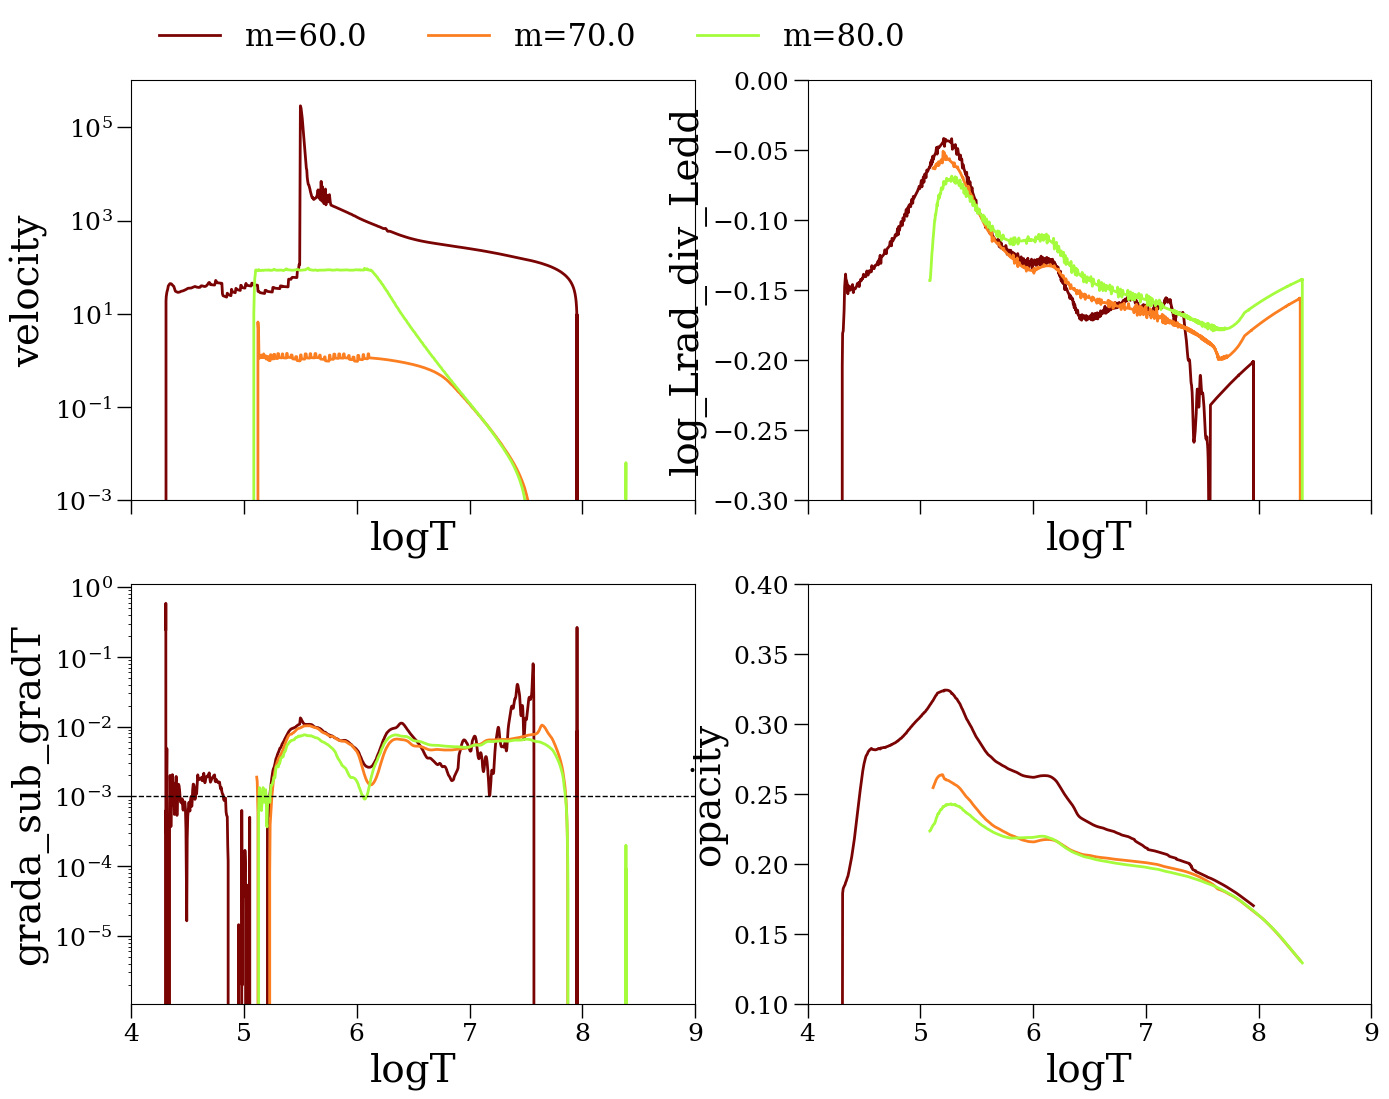

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
axes = axes.ravel()
inverted_xaxes = ['logtau', 'logT']

subcrashes_df = crashes_df[crashes_df.z_key == pick_z_key]

x_name = "logT"
y1_name = "velocity"
y2_name = "grada_sub_gradT"
y3_name = "log_Lrad_div_Ledd"
y4_name = "opacity"

invert_xaxis = x_name in inverted_xaxes

cmap = plt.cm.turbo
get_c = lambda mass: cmap(abs(mass-subcrashes_df.m_zams.max())/(subcrashes_df.m_zams.max()-subcrashes_df.m_zams.min()))


for index, data in subcrashes_df.iterrows():
    m_zams = data.m_zams
    p_zams = data.p_spin_zams
    c = get_c(m_zams)
    model = MesaModel(m_zams, p_zams, pick_z_key)
    final_profile_number, final_age, final_model_number = nearest_profile(model, age=1e10)
    x = get_profile_array(model, final_profile_number, x_name)
    y1 = get_profile_array(model, final_profile_number, y1_name)
    y2 = get_profile_array(model, final_profile_number, y2_name)
    y3 = get_profile_array(model, final_profile_number, y3_name)
    y4 = get_profile_array(model, final_profile_number, y4_name)
    axes[0].plot(x, y1, color=c, label=f'm={m_zams}')
    axes[2].plot(x, y2, color=c, label=f'm={m_zams}')
    axes[1].plot(x, y3, color=c, label=f'm={m_zams}')
    axes[3].plot(x, y4, color=c, label=f'm={m_zams}')
    if index > 1:
        break

axes[0].set_xlabel(x_name)
axes[0].set_ylabel(y1_name)
if invert_xaxis:
    axes[0].invert_xaxis()

axes[0].set_yscale('log')
axes[0].set_ylim(1e-3)
axes[0].legend(frameon=False, loc="lower left", bbox_to_anchor=(0,1), ncol=len(subcrashes_df)//2)

axes[2].set_xlabel(x_name)
axes[2].set_ylabel(y2_name)

axes[2].set_yscale('log')
axes[2].hlines(1e-3, 4, 9, color='k', ls='--', lw=1)
axes[2].set_xlim(4, 9)
#axes[2].set_ylim(1e-3)

axes[1].set_xlabel(x_name)
axes[1].set_ylabel(y3_name)
axes[1].set_ylim(-0.3, 0.)

axes[3].set_xlabel(x_name)
axes[3].set_ylabel(y4_name)
#axes[3].set_yscale('log')
axes[3].set_ylim(1e-1, 0.4)

Text(0, 0.5, 'brunt_N2')

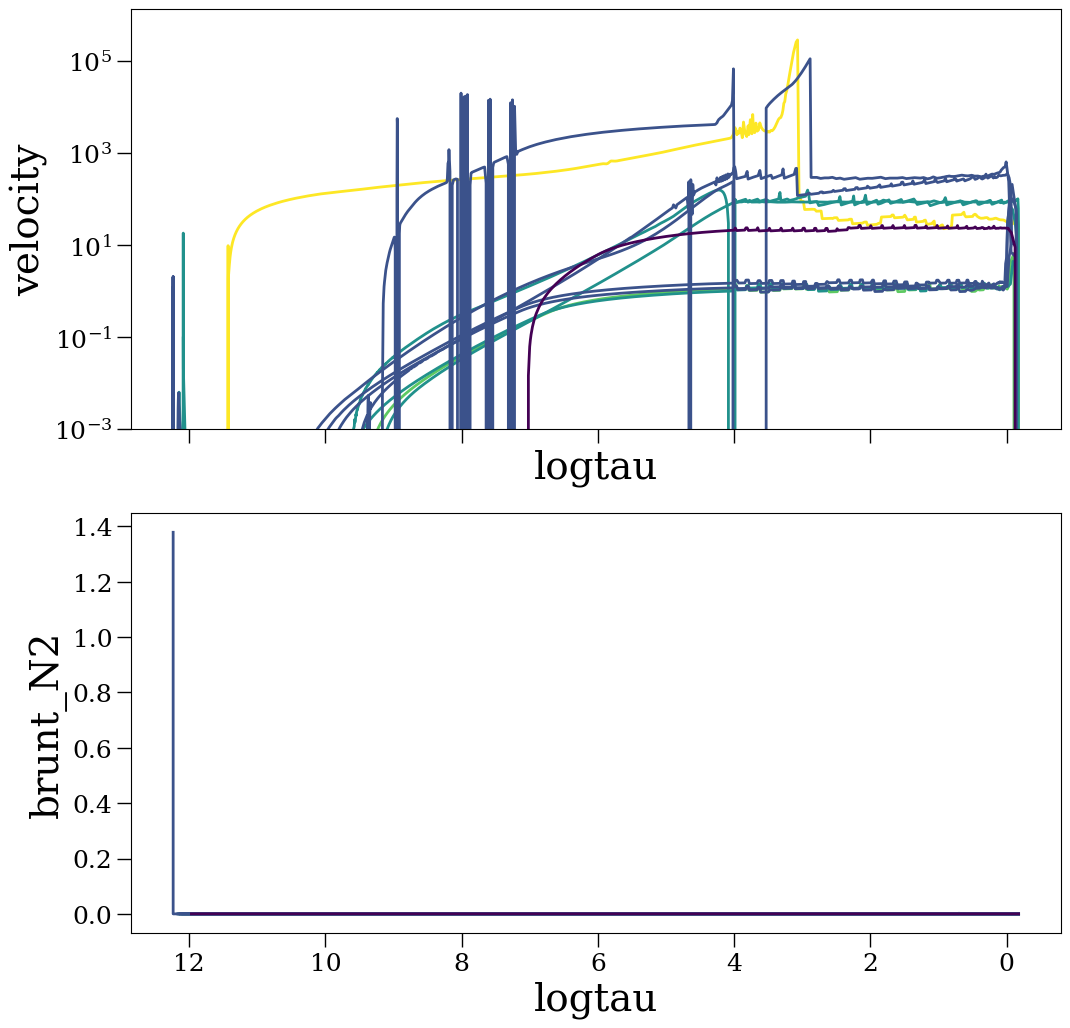

In [60]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=True)
inverted_xaxes = ['logtau', 'logT']

subcrashes_df = crashes_df[crashes_df.z_key == pick_z_key]

x_name = "logtau"
y1_name = "velocity"
y2_name = "brunt_N2"

invert_xaxis = x_name in inverted_xaxes

cmap = plt.cm.viridis
get_c = lambda mass: cmap(abs(mass-subcrashes_df.m_zams.max())/(subcrashes_df.m_zams.max()-subcrashes_df.m_zams.min()))


for index, data in subcrashes_df.iterrows():
    m_zams = data.m_zams
    p_zams = data.p_spin_zams
    c = get_c(m_zams)
    model = MesaModel(m_zams, p_zams, pick_z_key)
    final_profile_number, final_age, final_model_number = nearest_profile(model, age=1e10)
    x = get_profile_array(model, final_profile_number, x_name)
    y1 = get_profile_array(model, final_profile_number, y1_name)
    y2 = get_profile_array(model, final_profile_number, y2_name)
    axes[0].plot(x, y1, color=c, label=f'm={m_zams}')
    axes[1].plot(x, y2, color=c, label=f'm={m_zams}')

axes[0].set_xlabel(x_name)
axes[0].set_ylabel(y1_name)
if invert_xaxis:
    axes[0].invert_xaxis()

axes[0].set_yscale('log')
axes[0].set_ylim(1e-3)

axes[1].set_xlabel(x_name)
axes[1].set_ylabel(y2_name)

#axes[1].set_yscale('log')
#axes[1].set_ylim(1e-3)


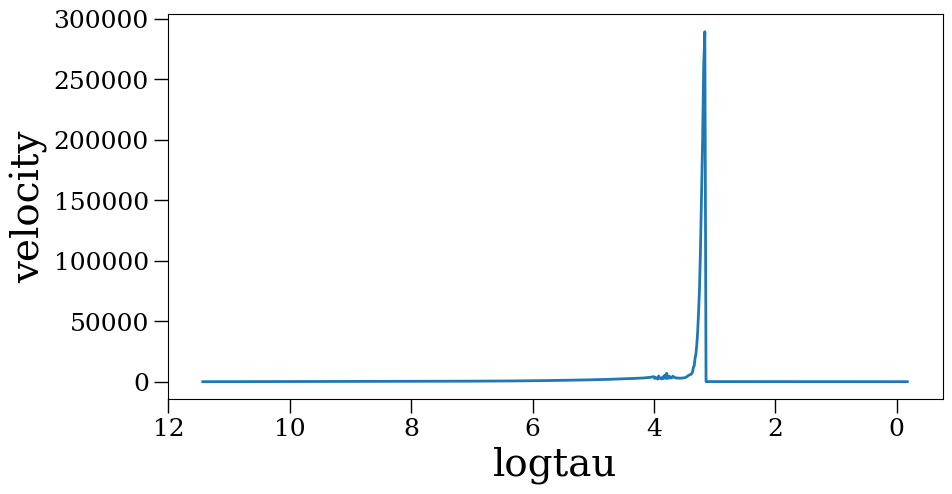

In [ ]:
x_name = "logtau"
y_name = "velocity"

inverted_xaxes = ['logtau']
invert_xaxis = x_name in inverted_xaxes

x = get_profile_array(model, final_profile_number, x_name)
y = get_profile_array(model, final_profile_number, y_name)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x, y)
ax.set_xlabel(x_name)
ax.set_ylabel(y_name)
if invert_xaxis:
    ax.invert_xaxis()

In [ ]:
def plot_simple_profile(ax, model, final_profile_number, x_name="logtau", y_name="velocity", c=None, label=None):
    x = get_profile_array(model, final_profile_number, x_name)
    y = get_profile_array(model, final_profile_number, y_name)

    ax.plot(x, y, c=c, label=label)

In [93]:
crashes_df.columns

Index(['z_key', 'm_zams', 'p_spin_zams', 'run_path', 'log_path',
       'termination_reason', 'crash_category', 'slurm_job_id',
       'runtime_hours'],
      dtype='object')

In [104]:
result = re.fullmatch('stop because*', 'stop because first omega > omega_crit   5.9427636155546080E-005   5.9338682873388241E-005')

In [105]:
print(result)

None


In [96]:
crashes_df.termination_reason.unique()

array(['stop because dt_div_kh <= dt_div_kh_minimum',
       'termination code: min_timestep_limit',
       'termination code: max_model_number',
       'stop because first omega > omega_crit   5.9427636155546080E-005   5.9338682873388241E-005',
       'stop because first omega > omega_crit   5.5596599064111971E-005   5.5258449285643782E-005',
       'stop because first omega > omega_crit   5.1803550678866390E-005   5.1600113907292826E-005',
       'stop because first omega > omega_crit   4.8300461363611054E-005   4.7548138527937364E-005',
       'stop because first omega > omega_crit   5.5988086509194963E-005   5.5216086958377315E-005',
       'stop because first omega > omega_crit   4.8086757481963479E-005   4.8029658347528162E-005',
       'stop because first omega > omega_crit   4.8308925917318423E-005   4.6819970078075621E-005',
       'stop because first omega > omega_crit   4.5142256499064904E-005   4.3698871246824449E-005',
       'stop because first omega > omega_crit   5.1310

/tmp/ipykernel_1378917/1624809552.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  final_profile_number = nearest_profile(model)[2]
/tmp/ipykernel_1378917/1624809552.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  final_profile_number = nearest_profile(model)[2]
/tmp/ipykernel_1378917/1624809552.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  final_profile_number = nearest_profile(model)[2]
/tmp/ipykernel_1378917/16248

Text(0.04, 0.5, 'velocity')

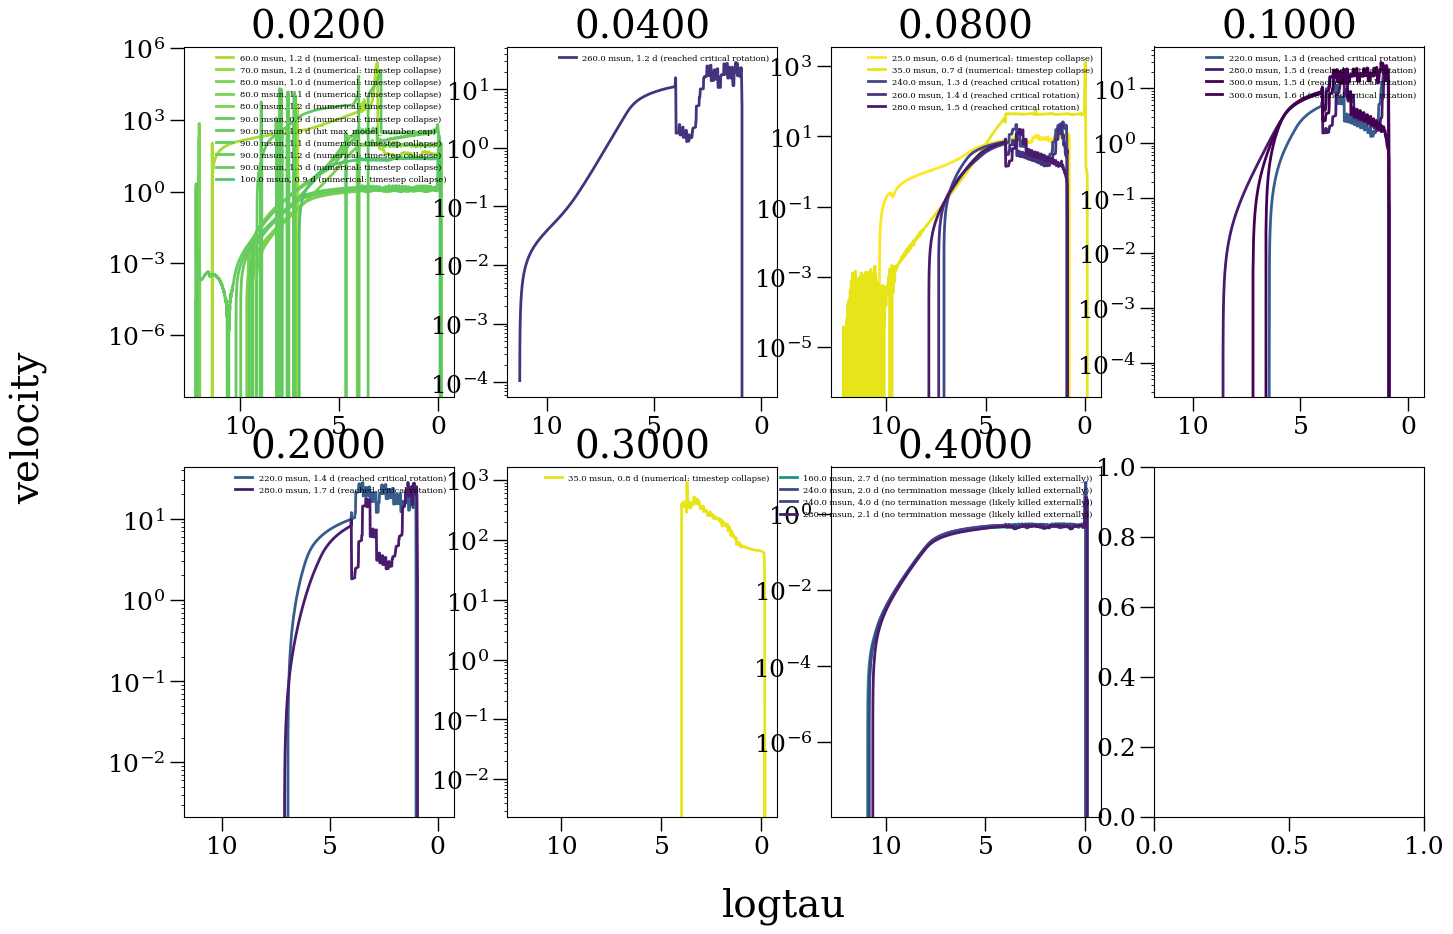

In [ ]:
x_name = 'logtau'
y_name = 'velocity'
cmap = plt.get_cmap('viridis')

inverted_xaxes = ['logtau']
invert_xaxis = x_name in inverted_xaxes


fig, axes = plt.subplots(2, 4, figsize=(16, 10))
unique_z_keys_sorted = crashes_df.z_key.unique()[np.argsort(crashes_df.z_key.unique().astype(float))]

get_cmap = lambda mass: cmap(abs(mass-crashes_df.m_zams.max())/(crashes_df.m_zams.max()-crashes_df.m_zams.min()))

for i, (ax, unique_z_key) in enumerate(zip(axes.ravel(), unique_z_keys_sorted)):
    for index, data in crashes_df[crashes_df.z_key == unique_z_key].iterrows():
        model = MesaModel(data.m_zams, data.p_spin_zams, data.z_key)
        final_profile_number = nearest_profile(model)[2]
        label = f"{data.m_zams} msun, {data.p_spin_zams} d ({data.crash_category})"
        plot_simple_profile(ax, model, final_profile_number, x_name, y_name, c=get_cmap(data.m_zams), label=label)
    ax.legend(frameon=False, loc='upper right', fontsize=6)
    ax.set_title(data.z_key)
    ax.set_yscale('log')
    if invert_xaxis:
        ax.invert_xaxis()

fig.text(0.5, 0.04, x_name, ha='center', va='top')
fig.text(0.04, 0.5, y_name, ha='right', va='center', rotation='vertical')

## 6. HRD per metallicity, with evolutionary milestones

One panel per `z_key`; every crashed model in that slice gets its HR track (via **b**) from ZAMS to the point it crashed, coloured by `crash_category` (section 2), with markers at each milestone in `MILESTONE_DEFS` it reached before doing so.


| milestone | source | condition |
|---|---|---|
| ZAMS | `extras_finish_step`, L620-622 + `inlist1` L40 | `L_nuc_burn_total / (Lsurf/Lsun) >= 0.9` (`Lnuc_div_L_zams_limit`) |
| H depletion | `extras_start_step`, L210 | `center_h1 <= 1e-6` |
| He ignition | (not in `run_star_extras.f90`) | `L_He >= 1d2` |
| He depletion | `extras_start_step`, L217-218 | `center_he4 <= 5e-3` and `center_h1 <= 0.5` |
| C depletion | `extras_start_step`, L225-227 | `center_c12 <= 1e-3` and `center_he4 <= 5e-3` and `center_h1 <= 0.5` |
| O depletion | `extras_start_step`, L234-237 | `center_o16 <= 0.1` and `center_c12 <= 1e-3` and `center_he4 <= 5e-3` and `center_h1 <= 0.5` |

`MILESTONE_DEFS` is the thing to edit: each entry is `name -> function(arrs) -> index into the history arrays (or None if never reached)`, where `arrs` is a dict of the columns named in `MILESTONE_COLUMNS`. Add a milestone by adding both its required column(s) to `MILESTONE_COLUMNS` (if not already there) and its entry to `MILESTONE_DEFS`.

In [45]:
def _first_true(mask):
    """Index of the first True in a boolean array, or None."""
    idx = np.where(mask)[0]
    return int(idx[0]) if len(idx) else None


MILESTONE_COLUMNS = ['log_L', 'log_Lnuc', 'log_LHe', 'center_h1', 'center_he4', 'center_c12', 'center_o16']

MILESTONE_DEFS = {
    # run_star_extras.f90 L620-622; inlist1 L40: Lnuc_div_L_zams_limit = 0.9d0
    'ZAMS':         lambda a: _first_true(10 ** a['log_Lnuc'] / 10 ** a['log_L'] >= 0.9),
    # run_star_extras.f90 L210: xa(ih1, nz) <= 1d-6
    'H depletion':  lambda a: _first_true(a['center_h1'] <= 1e-6),
    # not in run_star_extras.f90 -- L_He >= 1d2 Lsun, as instructed
    'He ignition':  lambda a: _first_true(a['log_LHe'] >= 2.0),
    # run_star_extras.f90 L217-218
    'He depletion': lambda a: _first_true((a['center_he4'] <= 5e-3) & (a['center_h1'] <= 0.5)),
    # run_star_extras.f90 L225-227
    'C depletion':  lambda a: _first_true(
        (a['center_c12'] <= 1e-3) & (a['center_he4'] <= 5e-3) & (a['center_h1'] <= 0.5)
    ),
    # run_star_extras.f90 L234-237
    'O depletion':  lambda a: _first_true(
        (a['center_o16'] <= 0.1) & (a['center_c12'] <= 1e-3)
        & (a['center_he4'] <= 5e-3) & (a['center_h1'] <= 0.5)
    ),
}

MILESTONE_MARKERS = {
    'ZAMS': 'o', 'H depletion': 's', 'He ignition': '^',
    'He depletion': 'D', 'C depletion': 'v', 'O depletion': 'X',
}
MILESTONE_COLORS = {
    name: plt.get_cmap('plasma')(t)
    for name, t in zip(MILESTONE_DEFS, np.linspace(0.05, 0.85, len(MILESTONE_DEFS)))
}

CRASH_CATEGORY_COLORS = {
    name: plt.get_cmap('tab10')(i)
    for i, name in enumerate(sorted(crashes_df.crash_category.unique()))
}

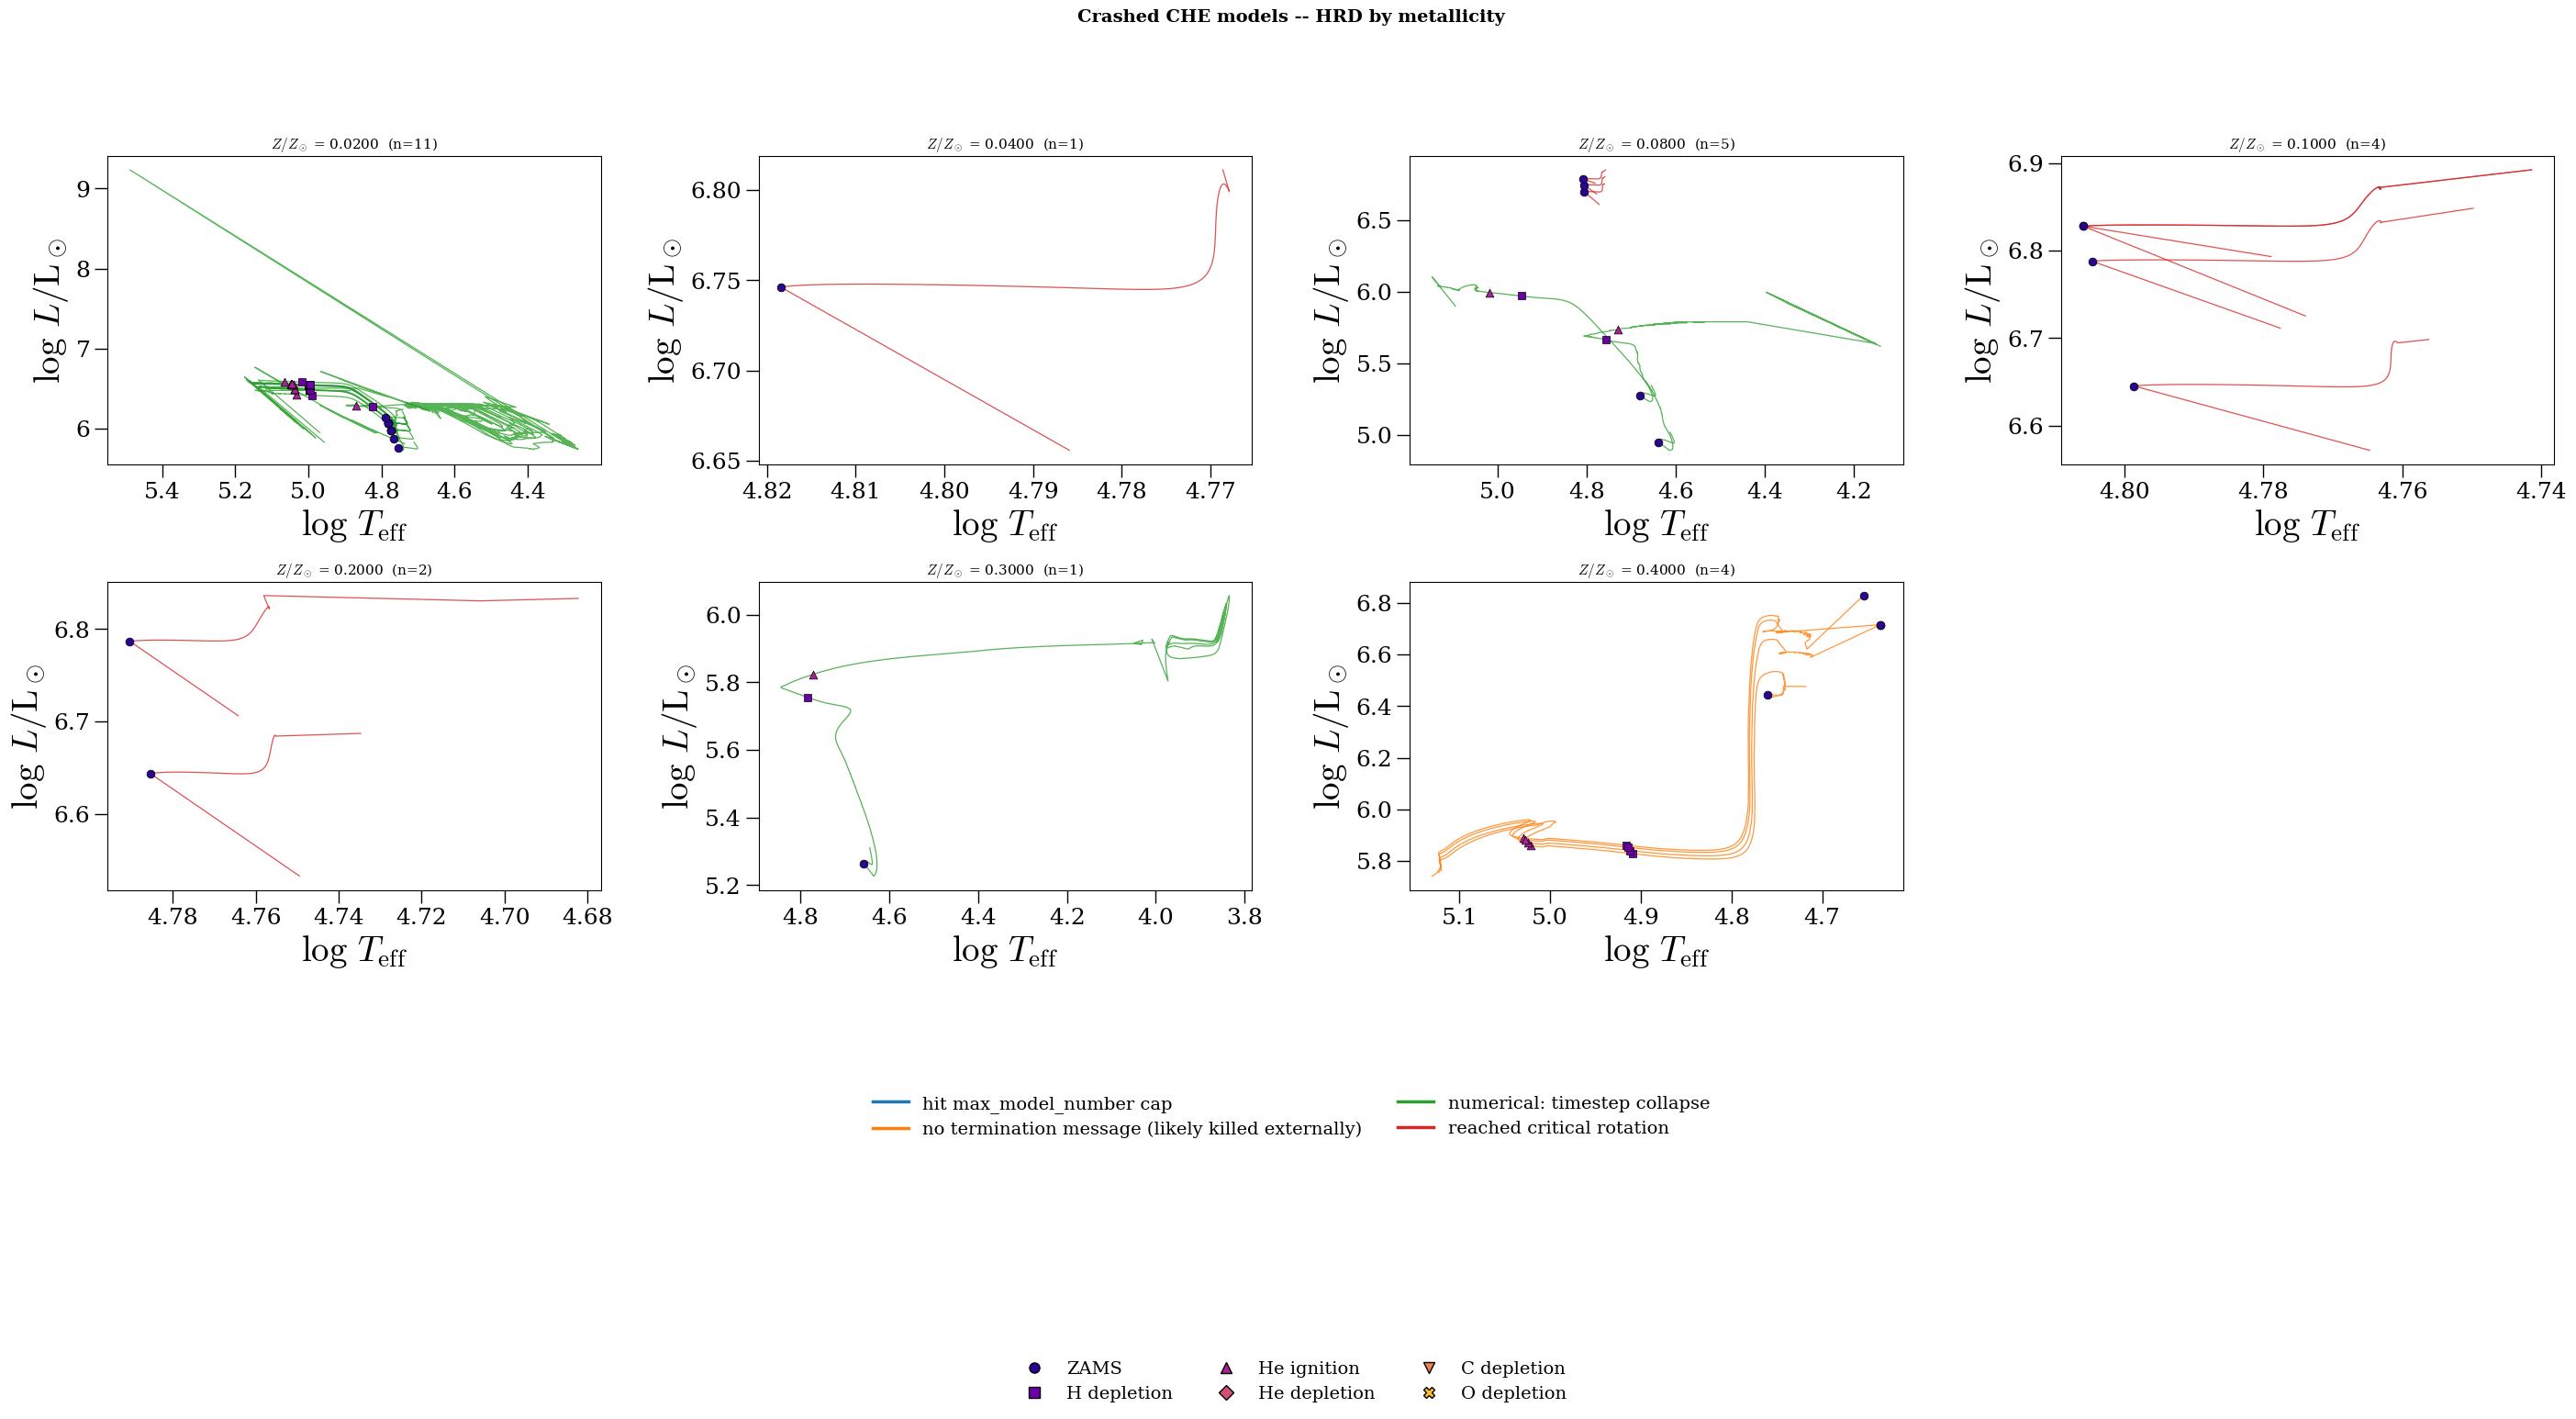

In [46]:
def plot_crash_hrd(crashes_df, ncols=4, figsize=None):
    z_keys = sorted(crashes_df.z_key.unique(), key=float)
    ncols = min(ncols, len(z_keys))
    nrows = int(np.ceil(len(z_keys) / ncols))
    figsize = figsize or (8.6 * ncols, 8.0 * nrows)
    fig, axs = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False,
                            gridspec_kw={'hspace': 0.38, 'wspace': 0.32})

    for ax, z_key in zip(axs.ravel(), z_keys):
        sub = crashes_df[crashes_df.z_key == z_key]
        for _, row in sub.iterrows():
            model = MesaModel(row.m_zams, row.p_spin_zams, row.z_key, crashes_df=crashes_df)
            teff = get_history_array(model, 'log_Teff')
            lum = get_history_array(model, 'log_L')
            track_color = CRASH_CATEGORY_COLORS[model.crash_category]
            ax.plot(teff, lum, '-', lw=0.9, color=track_color, alpha=0.8, zorder=2)

            arrs = {c: get_history_array(model, c) for c in MILESTONE_COLUMNS}
            for name, func in MILESTONE_DEFS.items():
                i = func(arrs)
                if i is None:
                    continue
                ax.scatter(teff[i], lum[i], marker=MILESTONE_MARKERS[name],
                           color=MILESTONE_COLORS[name], s=40, edgecolors='k',
                           linewidths=0.5, zorder=5)
        ax.invert_xaxis()
        ax.set_title(f'$Z/Z_\\odot$ = {z_key}  (n={len(sub)})', fontsize=11)
        ax.set_xlabel(r'$\log\,T_\mathrm{eff}$')
        ax.set_ylabel(r'$\log\,L/\mathrm{L}_\odot$')

    for ax in axs.ravel()[len(z_keys):]:
        ax.set_visible(False)

    milestone_handles = [
        plt.Line2D([0], [0], marker=MILESTONE_MARKERS[name], color='w',
                   markerfacecolor=MILESTONE_COLORS[name], markeredgecolor='k',
                   markersize=8, label=name)
        for name in MILESTONE_DEFS
    ]
    category_handles = [
        plt.Line2D([0], [0], color=color, lw=2.5, label=name)
        for name, color in CRASH_CATEGORY_COLORS.items()
    ]
    fig.subplots_adjust(bottom=0.38, hspace=0.55)
    fig.legend(handles=category_handles, loc='lower center', ncol=len(category_handles)//2,
               bbox_to_anchor=(0.5, 0.20), frameon=False, fontsize=14)
    fig.legend(handles=milestone_handles, loc='lower center', ncol=len(milestone_handles)//2,
               bbox_to_anchor=(0.5, 0.02), frameon=False, fontsize=14)
    fig.suptitle('Crashed CHE models -- HRD by metallicity', fontsize=14, fontweight='bold')
    return fig, axs


fig, axs = plot_crash_hrd(crashes_df)